## Data preparation

Plate reader data is loaded using `pr.load_platereader_data`, which parses the raw instrument 
output and merges the platemap to annotate each well with its construct identity.

Note: the tMangoIV and tMangoIV-RiboJ construct labels are suspected to be swapped in the 
platemap. A repeat experiment is pending to confirm.

In [ ]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [5]:
from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pr.plot_setup()

In [6]:
data, platemap = pr.load_platereader_data(
    data_file="20251027_Broccoli_mScarlet_test.txt", 
    platemap_file="20251027_Broccoli_mScarlet_platemap.tsv", 
    platereader="biotek-cdk"
)

## Timecourse analysis

### Full timecourse
The full timecourse plots show the raw fluorescence data for each construct across the entire 
experiment duration, excluding the negative control. Each trace represents the mean across three 
replicate wells with shaded regions indicating 95% confidence interval. The aptamer reporter 
(transcription) and mScarlet (translation) are plotted separately.

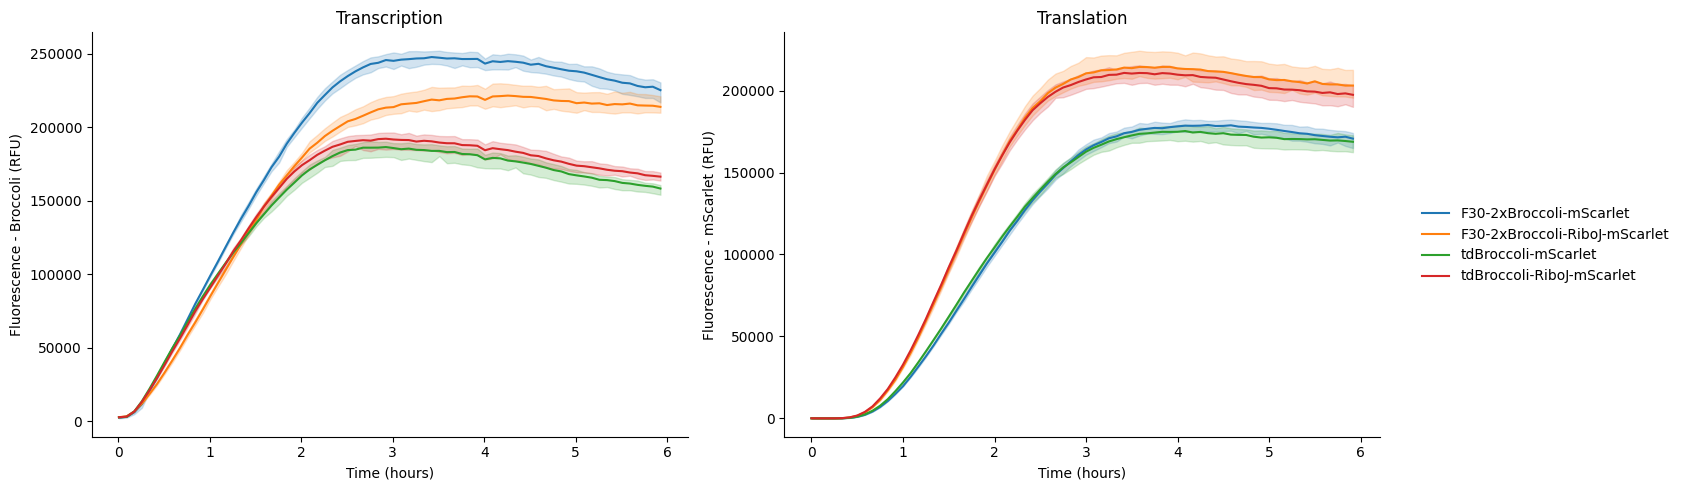

In [6]:
data["Time (hours)"] = data["Time"].dt.total_seconds() / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, read, ylabel in [
    (axes[0], "GFP-Gext", "Fluorescence - Broccoli (RFU)"),
    (axes[1], "mScarlet", "Fluorescence - mScarlet (RFU)")
]:
    subset = data[(data["Read"] == read) & (data["Name"] != "Negative")]
    sns.lineplot(data=subset, x="Time (hours)", y="Data", hue="Name", ax=ax)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()

axes[0].set_title("Transcription")
axes[1].set_title("Translation")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("./figures/Broccoli_mScarlet_full_timecourse.png", dpi=600, bbox_inches="tight")
plt.show()

### First hour
The first-hour plots show the early period of the experiment, split by aptamer variant to allow 
direct comparison of RiboJ and non-RiboJ constructs. Each trace represents the mean across three 
replicate wells with shaded regions indicating 95% confidence interval.

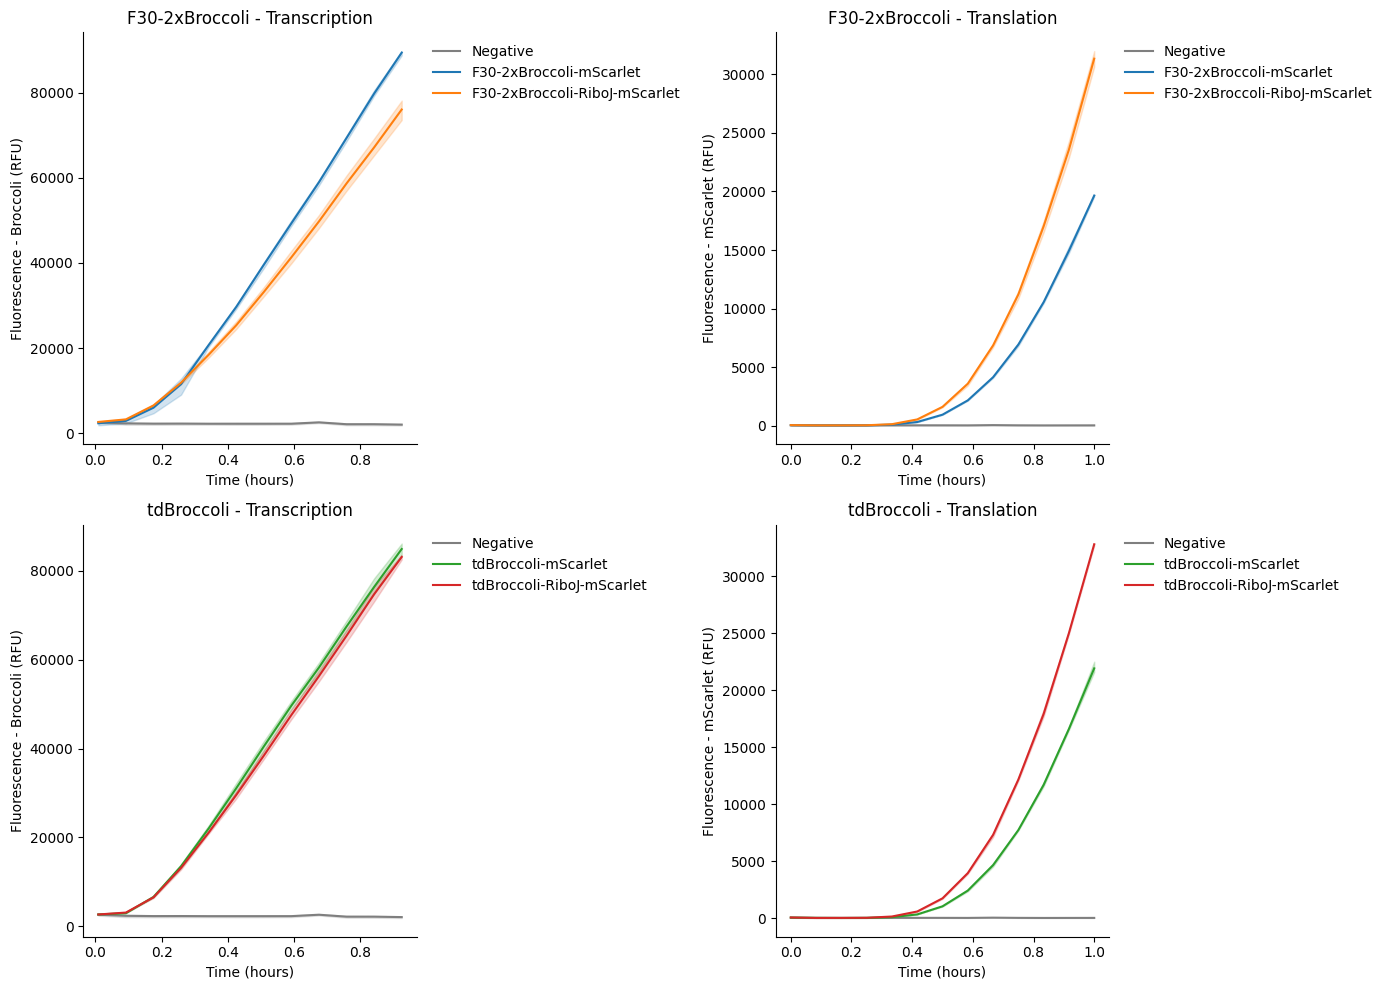

In [4]:
broccoli_colours = {
    "F30-2xBroccoli-mScarlet": "tab:blue",
    "F30-2xBroccoli-RiboJ-mScarlet": "tab:orange",
    "tdBroccoli-mScarlet": "tab:green",
    "tdBroccoli-RiboJ-mScarlet": "tab:red",
    "Negative": "tab:grey"
}
variants = {"F30-2xBroccoli": 0, "tdBroccoli": 1}
one_hour = pd.Timedelta("1 hour")
data["Time (hours)"] = data["Time"].dt.total_seconds() / 3600

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for variant, row in variants.items():
    names = list(data[data["Name"].str.contains(variant)]["Name"].unique()) + ["Negative"]
    for col, read, ylabel in [(0, "GFP-Gext", "Fluorescence - Broccoli (RFU)"),
                               (1, "mScarlet", "Fluorescence - mScarlet (RFU)")]:
        subset = data[
            (data["Read"] == read) &
            (data["Name"].isin(names)) &
            (data["Time"] <= one_hour)
        ]
        sns.lineplot(data=subset, x="Time (hours)", y="Data", hue="Name",
                     palette={n: broccoli_colours[n] for n in names},
                     ax=axes[row, col])
        axes[row, col].set_xlabel("Time (hours)")
        axes[row, col].set_ylabel(ylabel)
        axes[row, col].get_legend().remove()
    axes[row, 0].set_title(f"{variant} - Transcription")
    axes[row, 1].set_title(f"{variant} - Translation")
    for col in [0, 1]:
        handles, labels = axes[row, col].get_legend_handles_labels()
        axes[row, col].legend(handles, labels, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.savefig("./figures/Broccoli_mScarlet_first_hour.png", dpi=600, bbox_inches="tight")
plt.show()

## Kinetic analysis

Sigmoid drift curves are fitted to each replicate well individually using `pr.kinetic_analysis`. 
Lag times are extracted as the x-intercept of the tangent line at the inflection point of the 
fitted sigmoid. Lag times for the transcription reporter and mScarlet are plotted side by side 
per construct with error bars representing standard deviation across three replicate wells. The 
translation initiation delay is calculated as the difference between the mScarlet lag time and 
the aptamer lag time.

PROVIDING AVERAGED KINETICS
PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x7f8a0b27c690>,
                                                         Velocity            \
                                                             Time      Data   
 Name                          Read                                           
 F30-2xBroccoli-RiboJ-mScarlet GFP-Gext 0 days 01:11:07.032688954 110726.25   
 F30-2xBroccoli-mScarlet       GFP-Gext 0 days 01:14:32.009019311 123930.46   
 tdBroccoli-RiboJ-mScarlet     GFP-Gext 0 days 01:07:17.755051155 101348.18   
 tdBroccoli-mScarlet           GFP-Gext 0 days 01:05:31.537073823  93453.35   
 
                                                                        Lag  \
                                              Max                      Time   
 Name                          Read                                           
 F30-2xBroccoli-RiboJ-mScarlet GFP-Gext 117561.19 0 days 00:14:36.797863342   
 F30-2xBroccoli-mScarlet       GFP-Gext 142235.64 0 days 00:22:15.386211429   
 

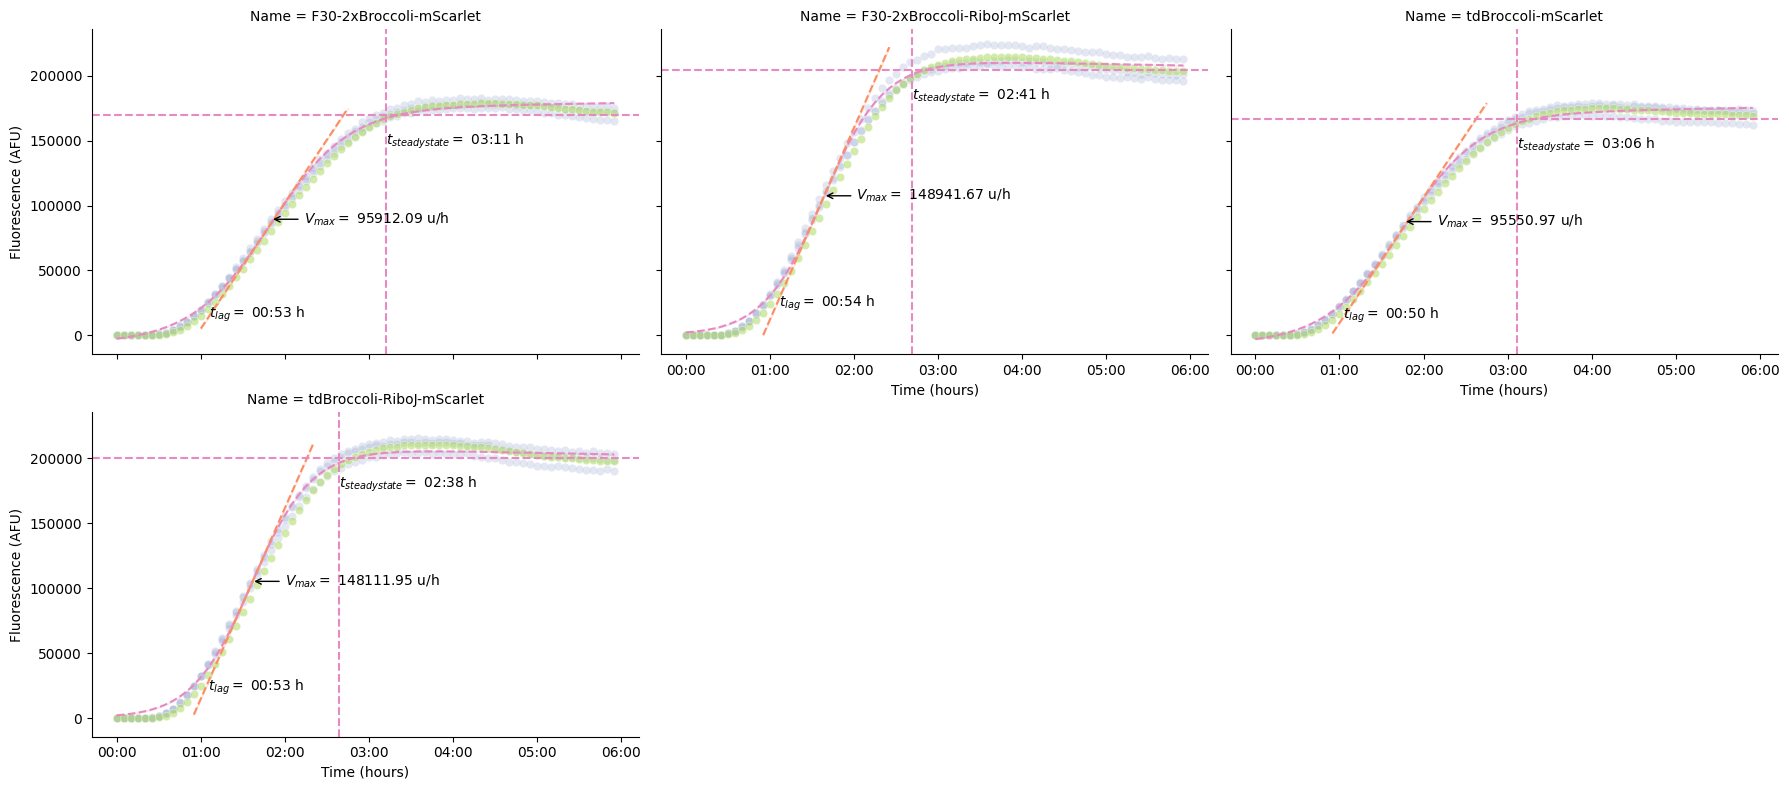

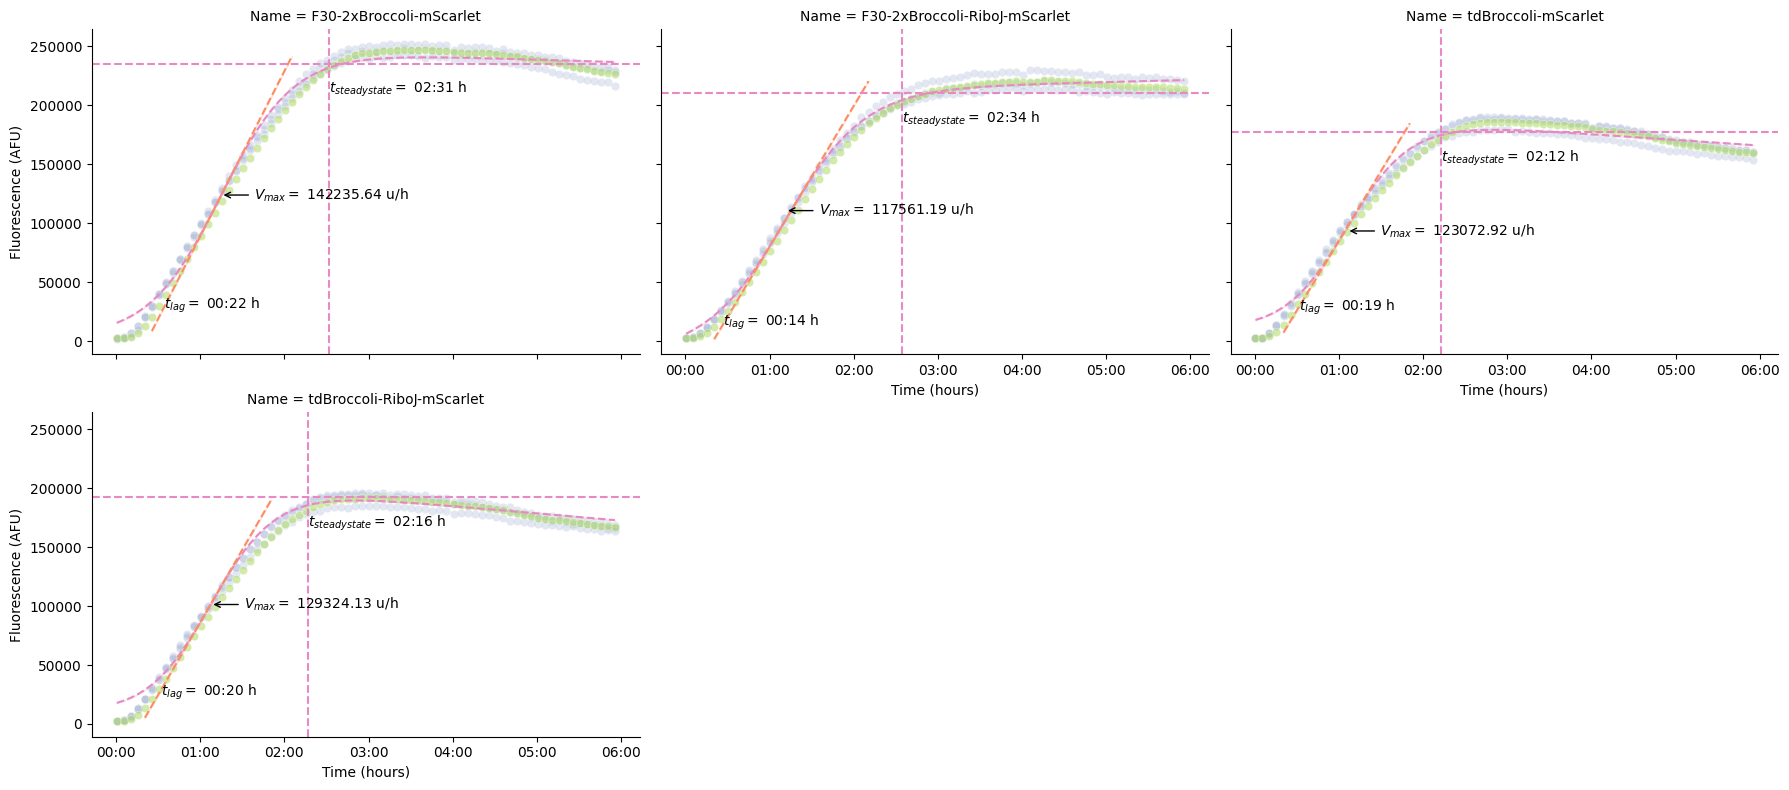

In [5]:
pr.plot_kinetics(data[(data["Name"] != "Negative") & (data["Read"] == "mScarlet")], group_by=["Name", "Read"])
pr.plot_kinetics(data[(data["Name"] != "Negative") & (data["Read"] == "GFP-Gext")], group_by=["Name", "Read"])

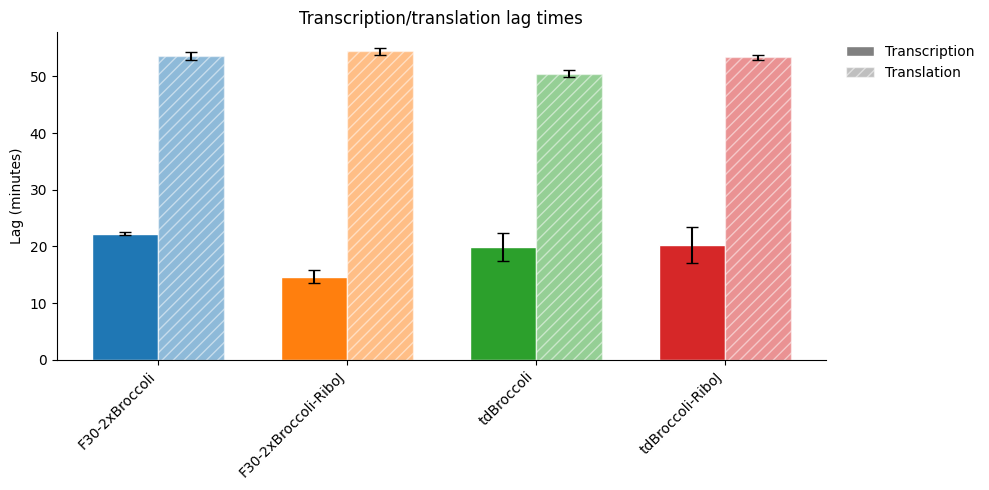

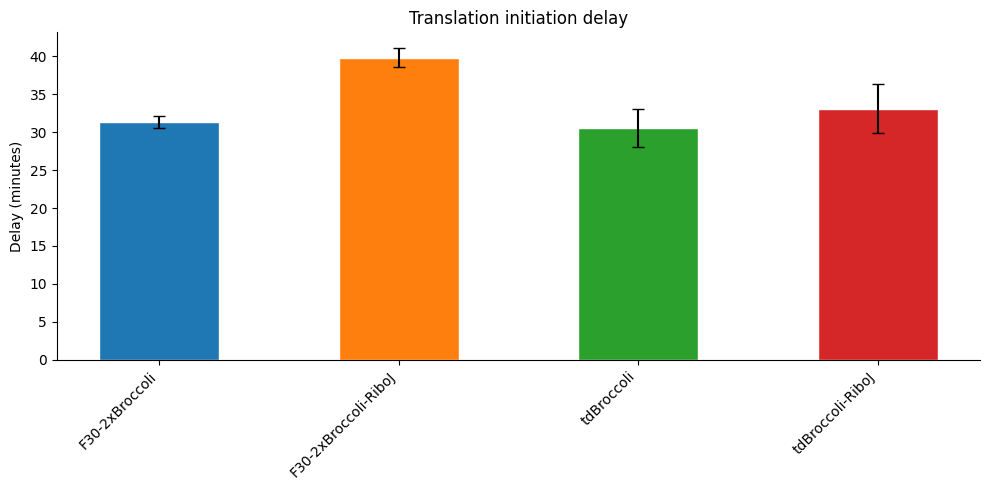

In [7]:
# Kinetic analysis using pr.kinetic_analysis
kinetics = pr.kinetic_analysis(data[data["Name"] != "Negative"], group_by=["Name", "Read", "Well"])

# Extract lag times in minutes
mScarlet_lag = kinetics.xs("mScarlet", level="Read")["Lag"]["Time"].dt.total_seconds() / 60
broccoli_lag = kinetics.xs("GFP-Gext", level="Read")["Lag"]["Time"].dt.total_seconds() / 60
broccoli_lag = broccoli_lag.clip(lower=0)

# Means and stds
mScarlet_mean = mScarlet_lag.groupby("Name").mean()
mScarlet_std = mScarlet_lag.groupby("Name").std()
broccoli_mean = broccoli_lag.groupby("Name").mean()
broccoli_std = broccoli_lag.groupby("Name").std()

# Save copies before plotting code can overwrite these variables
broccoli_lag_mean_saved = broccoli_mean.copy()
broccoli_lag_std_saved = broccoli_std.copy()
mScarlet_lag_mean_saved = mScarlet_mean.copy()
mScarlet_lag_std_saved = mScarlet_std.copy()

# Translation initiation delay
delay_mean = mScarlet_mean - broccoli_mean
delay_std = (mScarlet_std**2 + broccoli_std**2)**0.5

# Lag times plot
from matplotlib.patches import Patch
construct_colours = {
    "F30-2xBroccoli": "tab:blue",
    "F30-2xBroccoli-RiboJ": "tab:orange",
    "tdBroccoli": "tab:green",
    "tdBroccoli-RiboJ": "tab:red"
}

fig, ax = plt.subplots(figsize=(10, 5))
constructs = list(construct_colours.keys())
width = 0.35

for i, construct in enumerate(constructs):
    colour = construct_colours[construct]
    trans_mean = broccoli_mean.get(construct + "-mScarlet", 0)
    trans_std = broccoli_std.get(construct + "-mScarlet", 0)
    ax.bar(i - width/2, trans_mean, width, color=colour,
           yerr=trans_std, capsize=4, edgecolor="white")
    mscarlet_mean_val = mScarlet_mean.get(construct + "-mScarlet", 0)
    mscarlet_std_val = mScarlet_std.get(construct + "-mScarlet", 0)
    ax.bar(i + width/2, mscarlet_mean_val, width, color=colour, hatch="///",
           edgecolor="white", yerr=mscarlet_std_val, capsize=4, alpha=0.5)

ax.set_xticks(range(len(constructs)))
ax.set_xticklabels(constructs, rotation=45, ha="right")
ax.set_ylabel("Lag (minutes)")
ax.set_title("Transcription/translation lag times")
legend_elements = [
    Patch(facecolor="grey", edgecolor="white", label="Transcription"),
    Patch(facecolor="grey", hatch="///", edgecolor="white", alpha=0.5, label="Translation")
]
ax.legend(handles=legend_elements, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

# Translation initiation delay plot
fig, ax = plt.subplots(figsize=(10, 5))
for i, construct in enumerate(constructs):
    colour = construct_colours[construct]
    mean_val = delay_mean.get(construct + "-mScarlet", 0)
    std_val = delay_std.get(construct + "-mScarlet", 0)
    ax.bar(i, mean_val, width=0.5, color=colour, yerr=std_val, capsize=4, edgecolor="white")

ax.set_xticks(range(len(constructs)))
ax.set_xticklabels(constructs, rotation=45, ha="right")
ax.set_ylabel("Delay (minutes)")
ax.set_title("Translation initiation delay")
sns.despine()
plt.tight_layout()
plt.show()

## Reporter QC metrics

The following table summarises key quality metrics for each construct and reporter combination.

- **Lag detectable**: whether a distinct lag phase is observable before signal onset. A detectable
  lag phase is required to determine transcription or translation initiation time.
- **SNR** (signal-to-background ratio): fitted steady-state signal divided by the negative
  control steady-state signal. Higher values indicate cleaner signal above background noise.
- **R²**: goodness-of-fit of the sigmoid model to the timecourse data. Values close to 1.0
  indicate the sigmoid accurately describes the kinetics and lag time extraction is reliable.
- **Lag mean (min)**: mean fitted lag time across replicate wells — the time from reaction start
  to detectable signal onset.
- **Lag std (min)**: standard deviation of lag times across replicate wells in minutes. Lower
  values indicate more reproducible timing measurements.
- **Lag CV (%)**: coefficient of variation of the lag time (lag std / lag mean × 100). Lower
  values indicate the timing measurement uncertainty is small relative to the lag time itself.
- **Signal stability**: ratio of end-of-experiment signal to peak signal. Values close to 1.0
  indicate the reporter signal is stable throughout the experiment duration.


In [1]:
# QC Metrics Table

# Steady state SNR
steady_state = pr.find_steady_state(data, group_by=["Name", "Read", "Well"])
ss_data = steady_state["Data_steadystate"]
neg_ss = ss_data.xs("Negative", level="Name").groupby("Read").mean()
snr = (ss_data.groupby(["Name", "Read"]).mean() / neg_ss).drop("Negative", level="Name")

# R² from kinetics
r2 = kinetics["Fit"]["R^2"].groupby(["Name", "Read"]).mean()
r2.index.names = ["Name", "Read"]

# Signal stability
peak_signal = data[data["Name"] != "Negative"].groupby(["Name", "Read", "Well"])["Data"].max().groupby(["Name", "Read"]).mean()
end_signal = data.groupby(["Name", "Read"]).apply(
    lambda g: g.loc[g["Time"].idxmax(), "Data"]
).groupby(["Name", "Read"]).mean()
stability = (end_signal / peak_signal).drop("Negative", level="Name")

# Lag times
broccoli_lag_indexed = broccoli_lag_mean_saved.rename_axis("Name").to_frame("Lag mean (min)").assign(Read="GFP-Gext").set_index("Read", append=True)["Lag mean (min)"]
mScarlet_lag_indexed = mScarlet_lag_mean_saved.rename_axis("Name").to_frame("Lag mean (min)").assign(Read="mScarlet").set_index("Read", append=True)["Lag mean (min)"]
broccoli_std_indexed = broccoli_lag_std_saved.rename_axis("Name").to_frame("Lag std (min)").assign(Read="GFP-Gext").set_index("Read", append=True)["Lag std (min)"]
mScarlet_std_indexed = mScarlet_lag_std_saved.rename_axis("Name").to_frame("Lag std (min)").assign(Read="mScarlet").set_index("Read", append=True)["Lag std (min)"]

# Compile table
broccoli_table = pd.DataFrame({
    "SNR": snr.round(2),
    "R²": r2.round(4),
    "Signal stability": stability.round(2),
})
broccoli_table["Lag mean (min)"] = pd.concat([broccoli_lag_indexed, mScarlet_lag_indexed]).round(1)
broccoli_table["Lag std (min)"] = pd.concat([broccoli_std_indexed, mScarlet_std_indexed]).round(1)
broccoli_table["Lag CV (%)"] = (broccoli_table["Lag std (min)"] / broccoli_table["Lag mean (min)"] * 100).round(1)
broccoli_table["Lag detectable"] = ["Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes", "Yes"]

broccoli_table = broccoli_table[[
    "Lag detectable", "SNR", "R²", "Lag mean (min)",
    "Lag std (min)", "Lag CV (%)", "Signal stability"
]]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(broccoli_table)


NameError: name 'pr' is not defined

## Per-well kinetic fits

Individual sigmoid fits are shown for each replicate well to obtain a more accurate assessment 
of the aptamer lag time variance. Each plot shows the raw data points, the fitted sigmoid curve, 
the velocity tangent line at the inflection point, and the fitted lag time annotation. Constructs 
are grouped by aptamer variant with wells ordered by row (D, F, H).

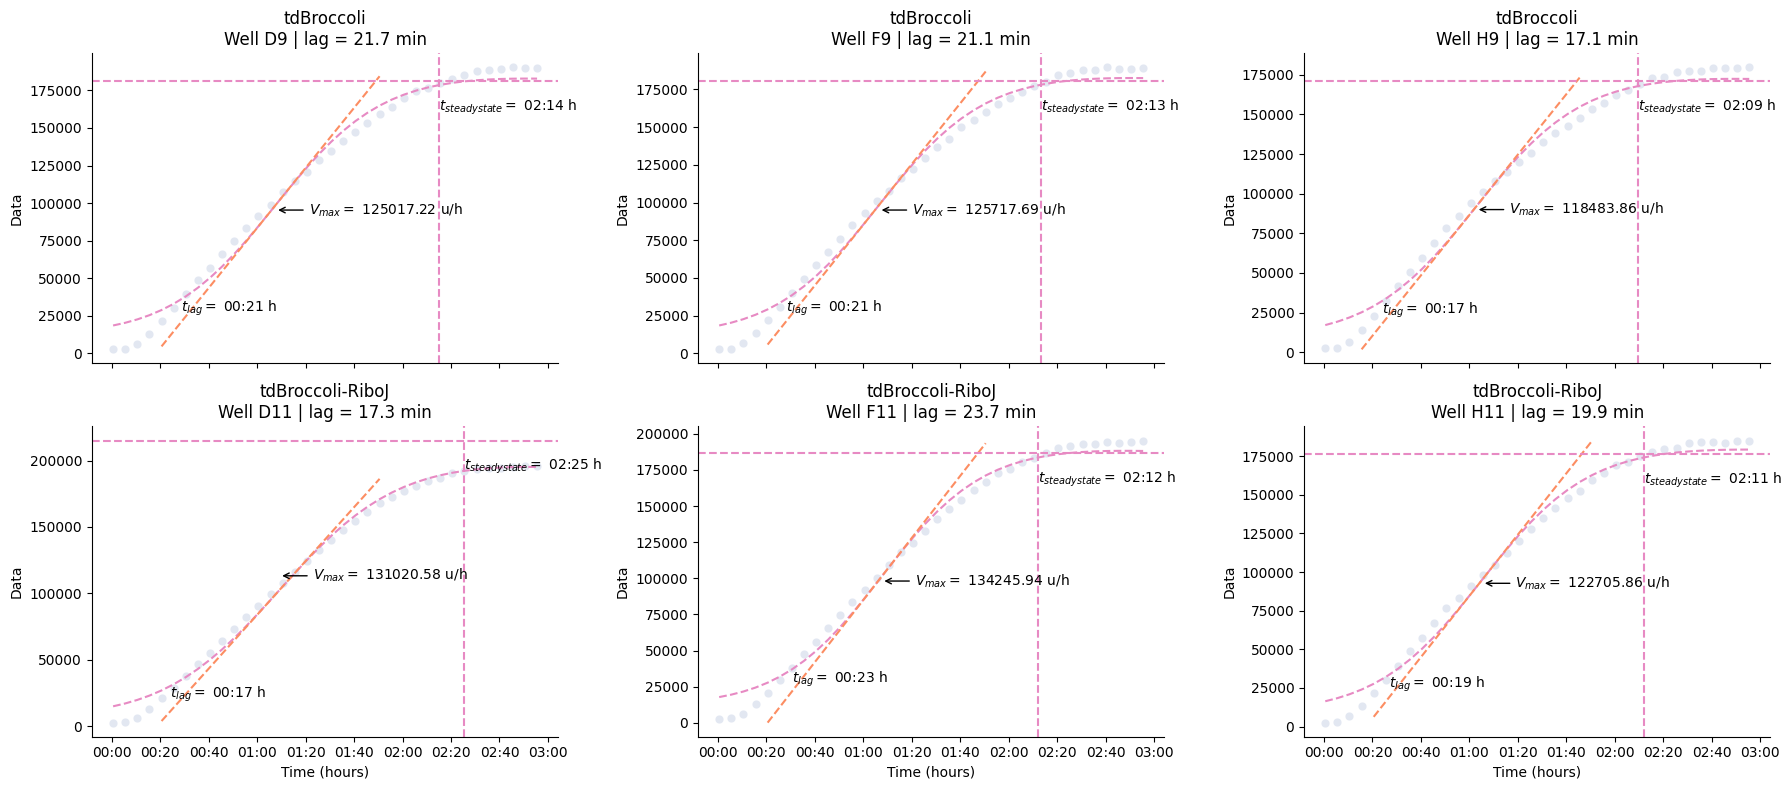

In [10]:
# tdBroccoli per-well kinetics
td_subset = data[
    (data["Name"].isin(["tdBroccoli-mScarlet", "tdBroccoli-RiboJ-mScarlet"])) &
    (data["Read"] == "GFP-Gext") &
    (data["Time"] <= pd.Timedelta("3 hours"))
].copy()

well_order_td = ["D9", "F9", "H9", "D11", "F11", "H11"]
td_subset["Well"] = pd.Categorical(td_subset["Well"], categories=well_order_td, ordered=True)
td_subset = td_subset.sort_values("Well")

g = sns.FacetGrid(td_subset, col="Well", col_wrap=3, sharey=False, height=4, aspect=1.5)
g.map_dataframe(pr.plot_kinetics_by_well, kinetics=kinetics,
                group_by=["Name", "Read", "Well"], show_fit=True, annotate=True)

for ax in g.axes.flat:
    title = ax.get_title()
    well = title.split(" = ")[1].strip()
    name = td_subset[td_subset["Well"] == well]["Name"].iloc[0]
    lag = kinetics.loc[(name, "GFP-Gext", well), "Lag"]["Time"].total_seconds() / 60
    ax.set_title(f"{name.replace('-mScarlet', '')}\nWell {well} | lag = {lag:.1f} min")

plt.tight_layout()
plt.show()

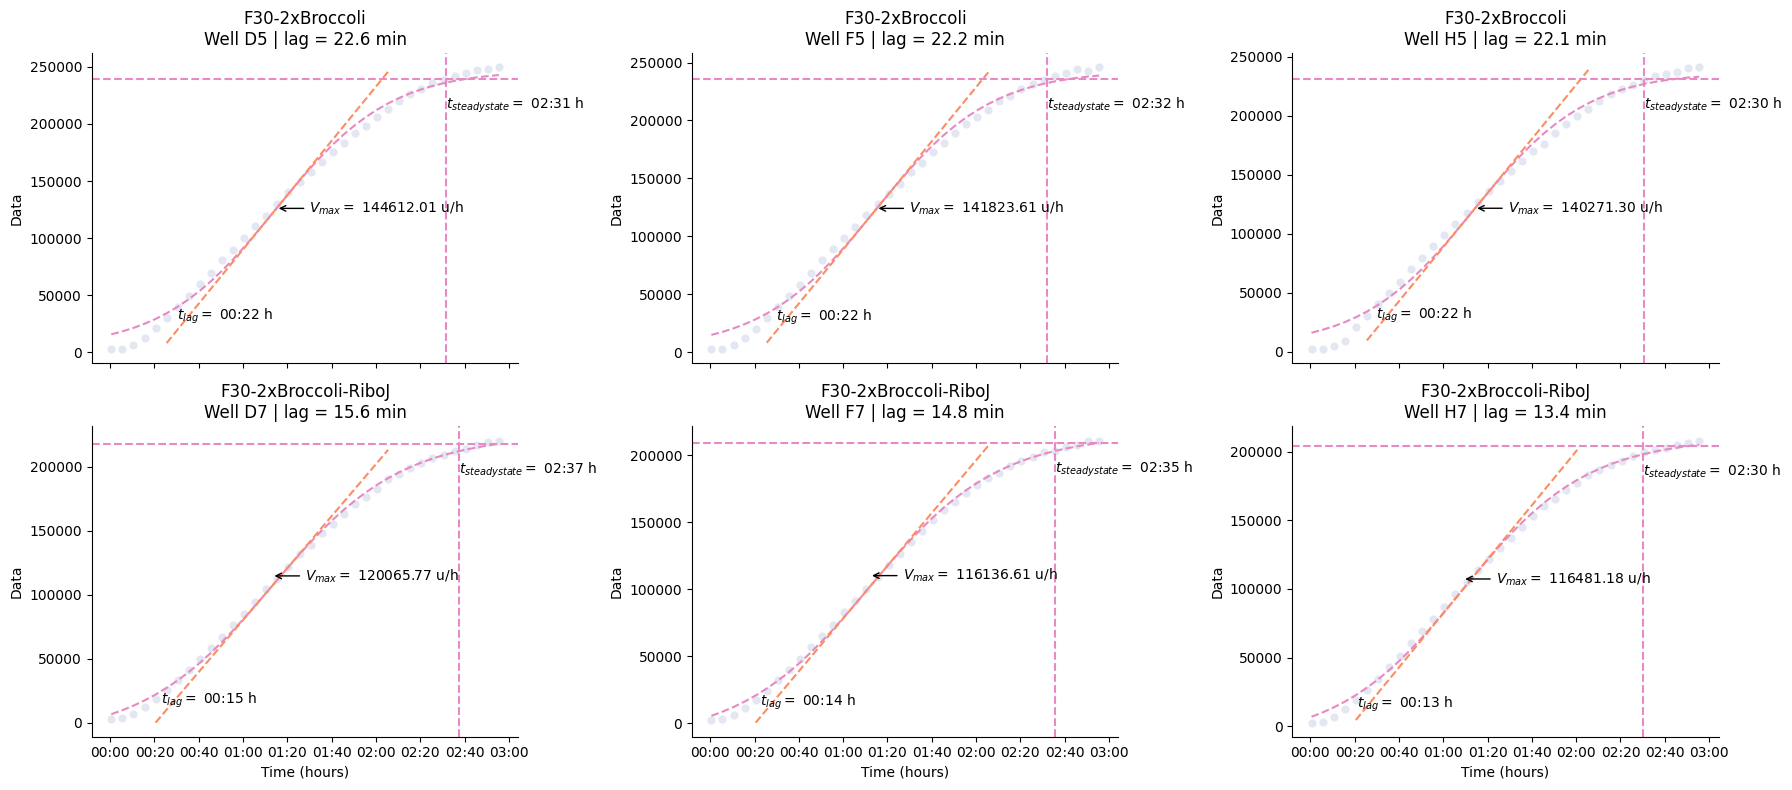

In [11]:
# F30-2xBroccoli per-well kinetics
f30_subset = data[
    (data["Name"].isin(["F30-2xBroccoli-mScarlet", "F30-2xBroccoli-RiboJ-mScarlet"])) &
    (data["Read"] == "GFP-Gext") &
    (data["Time"] <= pd.Timedelta("3 hours"))
].copy()

well_order_f30 = ["D5", "F5", "H5", "D7", "F7", "H7"]
f30_subset["Well"] = pd.Categorical(f30_subset["Well"], categories=well_order_f30, ordered=True)
f30_subset = f30_subset.sort_values("Well")

g = sns.FacetGrid(f30_subset, col="Well", col_wrap=3, sharey=False, height=4, aspect=1.5)
g.map_dataframe(pr.plot_kinetics_by_well, kinetics=kinetics,
                group_by=["Name", "Read", "Well"], show_fit=True, annotate=True)

for ax in g.axes.flat:
    title = ax.get_title()
    well = title.split(" = ")[1].strip()
    name = f30_subset[f30_subset["Well"] == well]["Name"].iloc[0]
    lag = kinetics.loc[(name, "GFP-Gext", well), "Lag"]["Time"].total_seconds() / 60
    ax.set_title(f"{name.replace('-mScarlet', '')}\nWell {well} | lag = {lag:.1f} min")

plt.tight_layout()
plt.show()

In [17]:
# From kinetics object for Broccoli
r2_broccoli = kinetics.xs("GFP-Gext", level="Read")["Fit"]["R^2"]
print("Broccoli R²:")
print(r2_broccoli.groupby("Name").mean())

# Signal to background
neg_signal = data[data["Name"] == "Negative"].groupby(["Time", "Read"])["Data"].mean()
ss_time = data["Time"].max() - pd.Timedelta("30 min")

for read in ["GFP-Gext", "mScarlet"]:
    neg_ss = data[(data["Name"] == "Negative") & (data["Read"] == read) & (data["Time"] >= ss_time)]["Data"].mean()
    for name in data[data["Name"] != "Negative"]["Name"].unique():
        signal_ss = data[(data["Name"] == name) & (data["Read"] == read) & (data["Time"] >= ss_time)]["Data"].mean()
        cv = data[(data["Name"] == name) & (data["Read"] == read)].groupby("Time")["Data"].std() / \
             data[(data["Name"] == name) & (data["Read"] == read)].groupby("Time")["Data"].mean() * 100
        print(f"{name} | {read} | SNR: {signal_ss/neg_ss:.2f} | CV: {cv.mean():.2f}%")

Broccoli R²:
Name
F30-2xBroccoli-RiboJ-mScarlet   1.00
F30-2xBroccoli-mScarlet         0.99
tdBroccoli-RiboJ-mScarlet       0.99
tdBroccoli-mScarlet             0.99
Name: R^2, dtype: float64
F30-2xBroccoli-mScarlet | GFP-Gext | SNR: 134.78 | CV: 2.82%
F30-2xBroccoli-RiboJ-mScarlet | GFP-Gext | SNR: 126.84 | CV: 2.93%
tdBroccoli-mScarlet | GFP-Gext | SNR: 94.85 | CV: 2.72%
tdBroccoli-RiboJ-mScarlet | GFP-Gext | SNR: 99.32 | CV: 2.58%
F30-2xBroccoli-mScarlet | mScarlet | SNR: 4313.36 | CV: 2.83%
F30-2xBroccoli-RiboJ-mScarlet | mScarlet | SNR: 5118.32 | CV: 4.23%
tdBroccoli-mScarlet | mScarlet | SNR: 4256.25 | CV: 3.12%
tdBroccoli-RiboJ-mScarlet | mScarlet | SNR: 4980.63 | CV: 3.31%


In [9]:
steady_state_broccoli = pr.find_steady_state(
    data,
    group_by=["Name", "Read", "Well"]
)

ss_data = steady_state_broccoli["Data_steadystate"]
neg_ss = ss_data.xs("Negative", level="Name").groupby("Read").mean()
snr = ss_data.groupby(["Name", "Read"]).mean() / neg_ss
snr = snr.drop("Negative", level="Name")

cv = data[data["Name"] != "Negative"].groupby(["Name", "Read", "Time"])["Data"].std() / \
     data[data["Name"] != "Negative"].groupby(["Name", "Read", "Time"])["Data"].mean() * 100
cv = cv.groupby(["Name", "Read"]).mean()

r2 = kinetics["Fit"]["R^2"].groupby(["Name", "Read"]).mean()

qc_table_broccoli = pd.DataFrame({
    "SNR": snr,
    "CV (%)": cv.round(2),
    "R²": r2.round(4),
})

print(qc_table_broccoli)

                                           SNR  CV (%)   R²
Name                          Read                         
F30-2xBroccoli-RiboJ-mScarlet GFP-Gext   84.43    2.93 1.00
                              mScarlet 2845.24    4.23 1.00
F30-2xBroccoli-mScarlet       GFP-Gext   94.50    2.82 0.99
                              mScarlet 2367.20    2.83 1.00
tdBroccoli-RiboJ-mScarlet     GFP-Gext   77.28    2.58 0.99
                              mScarlet 2789.55    3.31 1.00
tdBroccoli-mScarlet           GFP-Gext   71.26    2.72 0.99
                              mScarlet 2318.93    3.12 1.00


In [10]:
end_time = data["Time"].max()
end_signal = data[data["Time"] == end_time].groupby(["Name", "Read"])["Data"].mean()
ss_mean = steady_state_broccoli["Data_steadystate"].groupby(["Name", "Read"]).mean()
stability = (end_signal / ss_mean).drop("Negative", level="Name")
print(stability)

Name                           Read    
F30-2xBroccoli-RiboJ-mScarlet  GFP-Gext   1.02
                               mScarlet    NaN
F30-2xBroccoli-mScarlet        GFP-Gext   0.96
                               mScarlet    NaN
tdBroccoli-RiboJ-mScarlet      GFP-Gext   0.86
                               mScarlet    NaN
tdBroccoli-mScarlet            GFP-Gext   0.89
                               mScarlet    NaN
dtype: float64


In [11]:
print(data["Time"].max())
print(data[data["Read"] == "mScarlet"]["Time"].max())

0 days 05:55:31
0 days 05:55:00


In [12]:
peak_signal = data[data["Name"] != "Negative"].groupby(["Name", "Read", "Well"])["Data"].max().groupby(["Name", "Read"]).mean()
end_signal = data.groupby(["Name", "Read"]).apply(
    lambda g: g.loc[g["Time"].idxmax(), "Data"]
).groupby(["Name", "Read"]).mean()

stability = (end_signal / peak_signal).drop("Negative", level="Name")
print(stability)

Name                           Read    
F30-2xBroccoli-RiboJ-mScarlet  GFP-Gext   1.00
                               mScarlet   0.99
F30-2xBroccoli-mScarlet        GFP-Gext   0.93
                               mScarlet   0.98
tdBroccoli-RiboJ-mScarlet      GFP-Gext   0.88
                               mScarlet   0.96
tdBroccoli-mScarlet            GFP-Gext   0.86
                               mScarlet   0.98
dtype: float64


In [13]:

print(mScarlet_mean.round(1))
print(mScarlet_std.round(1))
print(broccoli_mean.round(1))
print(broccoli_std.round(1))


Name
F30-2xBroccoli-RiboJ-mScarlet   54.40
F30-2xBroccoli-mScarlet         53.60
tdBroccoli-RiboJ-mScarlet       53.40
tdBroccoli-mScarlet             50.50
Name: Time, dtype: float64
Name
F30-2xBroccoli-RiboJ-mScarlet   0.60
F30-2xBroccoli-mScarlet         0.70
tdBroccoli-RiboJ-mScarlet       0.40
tdBroccoli-mScarlet             0.60
Name: Time, dtype: float64
Name
F30-2xBroccoli-RiboJ-mScarlet   14.60
F30-2xBroccoli-mScarlet         22.30
tdBroccoli-RiboJ-mScarlet       20.30
tdBroccoli-mScarlet             20.00
Name: Time, dtype: float64
Name
F30-2xBroccoli-RiboJ-mScarlet   1.10
F30-2xBroccoli-mScarlet         0.30
tdBroccoli-RiboJ-mScarlet       3.20
tdBroccoli-mScarlet             2.50
Name: Time, dtype: float64


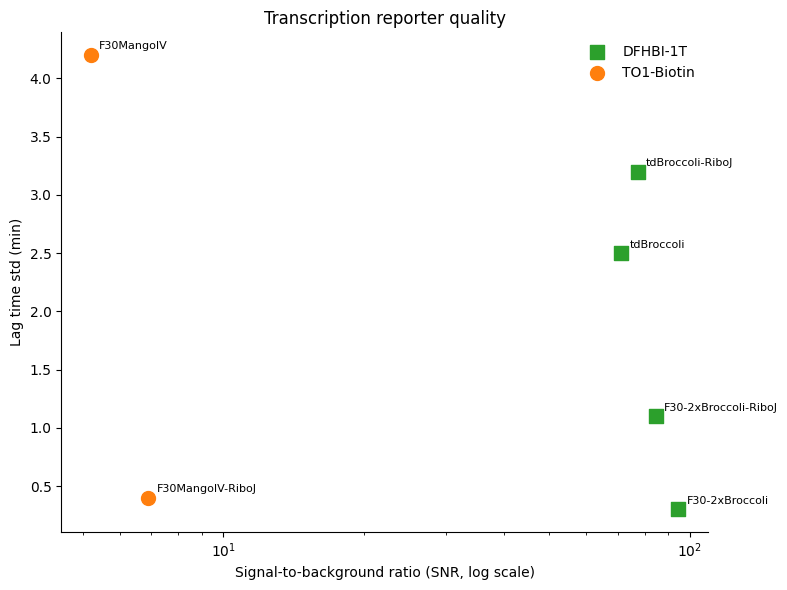

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

qc_plot_data = pd.DataFrame([
    {"Construct": "F30MangoIV", "Reporter": "TO1-Biotin", "SNR": 5.19, "Lag std (min)": 4.2},
    {"Construct": "F30MangoIV-RiboJ", "Reporter": "TO1-Biotin", "SNR": 6.90, "Lag std (min)": 0.4},
    {"Construct": "F30-2xBroccoli", "Reporter": "DFHBI-1T", "SNR": 94.50, "Lag std (min)": 0.3},
    {"Construct": "F30-2xBroccoli-RiboJ", "Reporter": "DFHBI-1T", "SNR": 84.43, "Lag std (min)": 1.1},
    {"Construct": "tdBroccoli", "Reporter": "DFHBI-1T", "SNR": 71.26, "Lag std (min)": 2.5},
    {"Construct": "tdBroccoli-RiboJ", "Reporter": "DFHBI-1T", "SNR": 77.28, "Lag std (min)": 3.2},
])

palette = {"TO1-Biotin": "tab:orange", "DFHBI-1T": "tab:green"}
markers = {"TO1-Biotin": "o", "DFHBI-1T": "s"}

fig, ax = plt.subplots(figsize=(8, 6))

for reporter, group in qc_plot_data.groupby("Reporter"):
    ax.scatter(group["SNR"], group["Lag std (min)"],
               color=palette[reporter], marker=markers[reporter],
               s=100, label=reporter, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(row["Construct"],
                    (row["SNR"], row["Lag std (min)"]),
                    textcoords="offset points", xytext=(6, 4),
                    fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("Signal-to-background ratio (SNR, log scale)")
ax.set_ylabel("Lag time std (min)")
ax.set_title("Transcription reporter quality")
ax.legend(title=None, frameon=False)



sns.despine()
plt.tight_layout()
plt.show()